In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm import tqdm

projectPath = Path.cwd().parents[1]
print(projectPath)

c:\Users\Hannes\projects\paper-revision


In [2]:
datapath = projectPath / "data" / "z_norm"
df = pd.read_parquet(projectPath / "data" / "ivdata.parquet")

In [3]:
NUMBER_OF_SLICES_PER_CLUSTER = 1
SAMPLES_PER_SLICE = 20

VOLA_DYNMICS_NUM_SLICES = 2
VOLA_DYNAMICS_CURVE_DIR = projectPath / "data" / "vola-dynamics"

def isValidSlice(key, group):
    z = group["z"].to_numpy()
    w = group["w"].to_numpy()
    
    validDataPoints = w.shape[0] - np.isnan(w).sum()
    
    return validDataPoints > 50
        

def sampleFromCluster(df):
    rng = np.random.default_rng()
    grouped = df.groupby(["Date", "Texp"])
    keys = list(grouped.groups.keys())

    selected = []
    tried = set()

    while len(selected) < NUMBER_OF_SLICES_PER_CLUSTER:
        if len(tried) == len(keys):
            raise RuntimeError("Not enough valid groups available.")

        group_idx = int(rng.integers(len(keys)))

        if group_idx in tried:
            continue

        tried.add(group_idx)

        key = keys[group_idx]
        group = grouped.get_group(key)

        if isValidSlice(key, group):
            selected.append(key)

    return selected


In [4]:
selectedKeys = []

for groupID, (groupLabel, group) in tqdm(list(enumerate(df.groupby("Group")))):
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_kmedoid_labels.npy")
    medoids = np.load(datapath / f"group_{groupID}_kmedoid_medoids.npy")
    
    for idx, cluster in enumerate(np.unique(labels), 1):
        keyIndex = pd.MultiIndex.from_tuples( [tuple(x) for x in keys[labels==cluster]], names=["Date", "Texp"])
        mask = pd.MultiIndex.from_frame(df[["Date", "Texp"]]).isin(keyIndex)
        selectedKeys += sampleFromCluster(df[mask])

100%|██████████| 5/5 [00:14<00:00,  2.93s/it]


In [39]:
def selectVolCurves(n, categoryOffset):
    result = None
    curveInfo = []
    curvePaths = [VOLA_DYNAMICS_CURVE_DIR / fname for fname in os.listdir(VOLA_DYNAMICS_CURVE_DIR) if "-25" in fname]
    for i in range(n):
        randCurveFile = np.random.choice(curvePaths)
        slices = np.load(randCurveFile)
        
        randSliceIdx = np.random.choice(slices.shape[0])
        randSlice = slices[randSliceIdx]
        
        randSlice[0, :] = randSlice[0, :] / np.abs(randSlice[0, :]).max()
        randSlice[1, :] = randSlice[1, :] / randSlice[1, :].max()
        
        values = randSlice.transpose()
        category = np.ones((values.shape[0], 1)) + i + categoryOffset
        valuesWithCategory = np.hstack([values, category])
        
        if result is None:
            result = valuesWithCategory
            
        else:
            result = np.vstack([result, valuesWithCategory])
            
        curveInfo.append((str(randCurveFile), int(randSliceIdx)))
            
    return result, curveInfo

In [40]:
def subsample(x, y, n):
    ix = np.linspace(x.min(), x.max(), n)
    return ix, np.interp(ix, x, y)

grouped = df.groupby(["Date", "Texp"])
data = [        ]
for category, key in enumerate(selectedKeys, 1):
    group = grouped.get_group(key)
    
    validMask = ~(group["w"].isna().to_numpy())
    z = group["z"].to_numpy()[validMask]
    w = group["w"].to_numpy()[validMask]
    
    w = w / w.max()
    z = z / abs(z).max()
    
    iz, iw = subsample(z, w, SAMPLES_PER_SLICE)
    
    data.append(np.array([
        iz, iw, category * np.ones_like(iz)
    ]).T)

    print("Total length", len(group))
    print("Valid data-points", len(group) - group["w"].isna().sum(), "->", group["w"].isna().sum(), "(NaN Values)")


data = np.vstack(data)

volaData, volaInfo = selectVolCurves(VOLA_DYNMICS_NUM_SLICES, len(selectedKeys))
data = np.vstack([data, volaData])

np.save(projectPath / "data" / "search" / "keys.npy", selectedKeys)
np.save(projectPath / "data" / "search" / "data.npy", data)
with open(projectPath / "data" / "search" / "vola-keys.txt", "w") as file:
    file.write(str(volaInfo))

randCategory = np.random.randint(0, len(selectedKeys))
randCategory = 21
simpleData = data[data[:, 2]==randCategory][:, [0, 1]]
np.save(projectPath / "data" / "search" / "data-simple.npy", simpleData)

Total length 185
Valid data-points 56 -> 129 (NaN Values)
Total length 172
Valid data-points 138 -> 34 (NaN Values)
Total length 148
Valid data-points 117 -> 31 (NaN Values)
Total length 156
Valid data-points 128 -> 28 (NaN Values)
Total length 183
Valid data-points 161 -> 22 (NaN Values)
Total length 107
Valid data-points 100 -> 7 (NaN Values)
Total length 123
Valid data-points 115 -> 8 (NaN Values)
Total length 208
Valid data-points 175 -> 33 (NaN Values)
Total length 83
Valid data-points 74 -> 9 (NaN Values)
Total length 139
Valid data-points 133 -> 6 (NaN Values)
Total length 123
Valid data-points 116 -> 7 (NaN Values)
Total length 374
Valid data-points 362 -> 12 (NaN Values)
Total length 134
Valid data-points 134 -> 0 (NaN Values)
Total length 254
Valid data-points 246 -> 8 (NaN Values)
Total length 115
Valid data-points 115 -> 0 (NaN Values)
Total length 60
Valid data-points 53 -> 7 (NaN Values)
Total length 110
Valid data-points 109 -> 1 (NaN Values)
Total length 90
Valid data-p

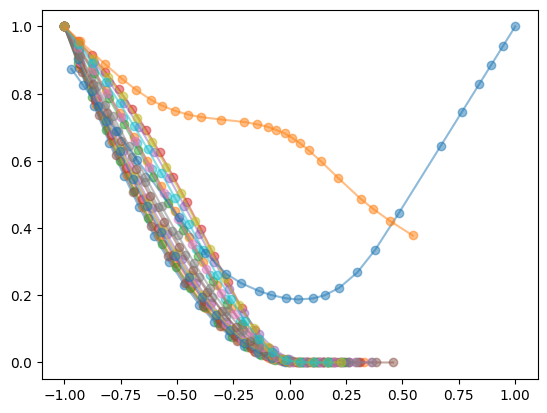

In [41]:
categories = np.unique(data[:, 2])
for category in categories:
    catData = data[data[:, 2]==category]
    x = catData[:, 0]
    y = catData[:, 1]
    
    plt.plot(x, y, alpha=0.5, marker="o")
plt.show()

In [ ]:
for category, key in enumerate(selectedKeys, 1):
    group = grouped.get_group(key)
    
    validMask = ~(group["w"].isna().to_numpy())
    z = group["z"].to_numpy()[validMask]
    w = group["w"].to_numpy()[validMask]
    
    w = w / w.max()
    # z = z / abs(z).max()
    
    iz, iw = subsample(z, w, 20)
    
    plt.plot(z, w, alpha=0.5, marker="o")
plt.show()